# CSE438 Lab 13: Lab Exam and Viva Examination

**Course:** CSE438 — Digital Image Processing  
**Dataset:** Betel Leaf Image Dataset from Bangladesh  
**Environment:** Kaggle Notebook  
**Instructor:** Dr. Md. Rifat Ahmmad Rashid  

This notebook is designed as a **lab-exam workspace**. It gives students a clean structure for solving an assigned image-processing problem, generating required outputs, and preparing for viva questions across the laboratory topics covered in CSE438.

Unlike the previous tutorial-oriented labs, this notebook does not prescribe a single fixed solution. The examiner may assign one of the problems from the problem bank or provide a separate unseen task during the examination.

## Learning Objectives

After completing this lab examination, students should be able to:

1. demonstrate competency in core Digital Image Processing laboratory topics;
2. solve an unseen image-processing problem using Python, OpenCV, NumPy, Matplotlib, and scikit-image;
3. select appropriate preprocessing, enhancement, filtering, segmentation, restoration, or morphology operations;
4. submit working code with meaningful visual and quantitative outputs;
5. answer viva questions related to image representation, filtering, enhancement, segmentation, restoration, morphology, and evaluation.

## Lab Exam Tasks

1. Solve the assigned lab problem independently.  
2. Submit working code and output images/tables.  
3. Answer **3–5 viva questions** from the examiner.

The notebook contains a problem bank for practice and controlled assessment. The examiner may change the assigned problem, image class, image index, or required output.

## Assessment-Oriented Instructions

- Keep the solution code readable and reproducible.
- Use comments to explain major processing steps.
- Show both intermediate and final outputs.
- Save important output images in the working directory.
- Use quantitative measures whenever the problem allows it.
- Avoid deleting cells that show your reasoning or intermediate results.
- Do not use external pretrained models unless the examiner explicitly permits them.

In [1]:
# ============================================================
# Lab 13 Setup
# ============================================================

import os
import math
import shutil
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage import exposure, filters, morphology, measure
from skimage.metrics import structural_similarity
from scipy import ndimage

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = False

OUTPUT_DIR = Path("/kaggle/working/cse438_lab13_exam_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("OpenCV version:", cv2.__version__)
print("NumPy version:", np.__version__)
print("Output directory:", OUTPUT_DIR)

OpenCV version: 4.13.0
NumPy version: 2.4.6
Output directory: /kaggle/working/cse438_lab13_exam_outputs


In [2]:
# ============================================================
# Dataset Path Configuration
# ============================================================
# The dataset may be mounted under slightly different Kaggle paths.
# This cell checks common paths and searches /kaggle/input if needed.

CLASS_NAMES = [
    "Bacterial Leaf Disease",
    "Dried Leaf",
    "Fungal Brown Spot Disease",
    "Healthy Leaf",
]

CANDIDATE_ROOTS = [
    Path("/kaggle/input/datasets/rifat963/betel-leaf-image-dataset-from-bangladesh"),
    Path("/kaggle/input/betel-leaf-image-dataset-from-bangladesh"),
    Path("/kaggle/input/betel-leaf-image-dataset-from-bangladesh/data"),
    Path("/kaggle/input/datasets/rifat963/betel-leaf-image-dataset-from-bangladesh/data"),
]

def has_expected_structure(root: Path) -> bool:
    train_dir = root / "train"
    test_dir = root / "test"
    if not train_dir.exists() or not test_dir.exists():
        return False
    return any((train_dir / cls).exists() for cls in CLASS_NAMES)

def find_dataset_root() -> Path:
    for root in CANDIDATE_ROOTS:
        if has_expected_structure(root):
            return root

    input_root = Path("/kaggle/input")
    if input_root.exists():
        for candidate in input_root.rglob("*"):
            if candidate.is_dir() and has_expected_structure(candidate):
                return candidate

    raise FileNotFoundError(
        "Could not locate the Betel Leaf dataset. "
        "Please add the Kaggle dataset to this notebook and verify the folder contains train/ and test/."
    )

DATASET_ROOT = find_dataset_root()
TRAIN_DIR = DATASET_ROOT / "train"
TEST_DIR = DATASET_ROOT / "test"

print("Dataset root:", DATASET_ROOT)
print("Train directory:", TRAIN_DIR)
print("Test directory:", TEST_DIR)

Dataset root: /kaggle/input/datasets/rifat963/betel-leaf-image-dataset-from-bangladesh
Train directory: /kaggle/input/datasets/rifat963/betel-leaf-image-dataset-from-bangladesh/train
Test directory: /kaggle/input/datasets/rifat963/betel-leaf-image-dataset-from-bangladesh/test


In [3]:
# ============================================================
# Dataset Summary
# ============================================================

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

def list_image_files(folder: Path):
    return sorted([
        p for p in folder.rglob("*")
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ])

summary_rows = []
for split_name, split_dir in [("train", TRAIN_DIR), ("test", TEST_DIR)]:
    for cls in CLASS_NAMES:
        cls_dir = split_dir / cls
        count = len(list_image_files(cls_dir)) if cls_dir.exists() else 0
        summary_rows.append({
            "split": split_name,
            "class": cls,
            "image_count": count,
        })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

print("Total images:", int(summary_df["image_count"].sum()))

,split,class,image_count
0,train,Bacterial Leaf Disease,609
1,train,Dried Leaf,597
2,train,Fungal Brown Spot Disease,588
3,train,Healthy Leaf,594
4,test,Bacterial Leaf Disease,47
5,test,Dried Leaf,51
6,test,Fungal Brown Spot Disease,54
7,test,Healthy Leaf,49


Total images: 2589


In [4]:
# ============================================================
# Utility Functions
# ============================================================

def read_rgb(path: Path, target_size=(512, 512)):
    """
    Read an image using OpenCV, convert BGR to RGB, and resize it.
    """
    bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if bgr is None:
        raise ValueError(f"Could not read image: {path}")
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    if target_size is not None:
        rgb = cv2.resize(rgb, target_size, interpolation=cv2.INTER_AREA)
    return rgb

def to_gray(rgb):
    """
    Convert an RGB image to grayscale.
    """
    return cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)

def ensure_uint8(image):
    """
    Convert an image to uint8 in the valid range [0, 255].
    """
    image = np.asarray(image)
    if image.dtype == np.uint8:
        return image
    image = np.clip(image, 0, 255)
    return image.astype(np.uint8)

def normalize_to_uint8(image):
    """
    Normalize an image to [0, 255] and convert it to uint8.
    """
    image = np.asarray(image, dtype=np.float32)
    min_val = float(np.min(image))
    max_val = float(np.max(image))
    if max_val - min_val < 1e-8:
        return np.zeros_like(image, dtype=np.uint8)
    normalized = (image - min_val) / (max_val - min_val)
    return (normalized * 255).astype(np.uint8)

def show_images(images, titles, cols=3, figsize=(14, 8), cmap=None):
    """
    Display multiple images in a compact grid.
    """
    rows = int(np.ceil(len(images) / cols))
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles), start=1):
        plt.subplot(rows, cols, i)
        if img.ndim == 2:
            plt.imshow(img, cmap=cmap or "gray")
        else:
            plt.imshow(img)
        plt.title(title)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

def save_image_rgb_or_gray(image, filename):
    """
    Save RGB or grayscale image using OpenCV.
    """
    path = OUTPUT_DIR / filename
    if image.ndim == 2:
        cv2.imwrite(str(path), image)
    else:
        bgr = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
        cv2.imwrite(str(path), bgr)
    return path

def mse(reference, test):
    """
    Mean squared error between two images.
    """
    reference = reference.astype(np.float32)
    test = test.astype(np.float32)
    return float(np.mean((reference - test) ** 2))

def psnr(reference, test):
    """
    Peak Signal-to-Noise Ratio in dB.
    """
    value = mse(reference, test)
    if value == 0:
        return float("inf")
    return float(10 * np.log10((255 ** 2) / value))

def ssim_score(reference, test):
    """
    Structural Similarity Index for grayscale images.
    """
    return float(structural_similarity(reference, test, data_range=255))

def iou_score(mask_a, mask_b):
    """
    Intersection over Union for binary masks.
    """
    a = mask_a > 0
    b = mask_b > 0
    intersection = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    if union == 0:
        return 0.0
    return float(intersection / union)

def edge_density(edge_image):
    """
    Ratio of nonzero edge pixels to total pixels.
    """
    return float(np.count_nonzero(edge_image) / edge_image.size)

def laplacian_variance(gray):
    """
    A simple sharpness indicator based on the variance of the Laplacian response.
    """
    return float(cv2.Laplacian(gray, cv2.CV_64F).var())

def largest_component_mask(binary_mask):
    """
    Keep only the largest connected foreground component.
    """
    mask = (binary_mask > 0).astype(np.uint8)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)

    if num_labels <= 1:
        return (mask * 255).astype(np.uint8)

    foreground_stats = stats[1:, cv2.CC_STAT_AREA]
    largest_label = 1 + int(np.argmax(foreground_stats))
    largest = (labels == largest_label).astype(np.uint8) * 255
    return largest

print("Utility functions are ready.")

Utility functions are ready.


## 1. Select the Assigned Image

The examiner may set the class name and image index. Students should not rely on a single image, because an unseen image may have different illumination, contrast, texture, or disease pattern.

Selected image: /kaggle/input/datasets/rifat963/betel-leaf-image-dataset-from-bangladesh/train/Healthy Leaf/Healthy_Leaf-1-_jpg.rf.2bbab1284996789ca5375cbca7337959.jpg
RGB shape: (512, 512, 3)
Grayscale shape: (512, 512)
Data type: uint8


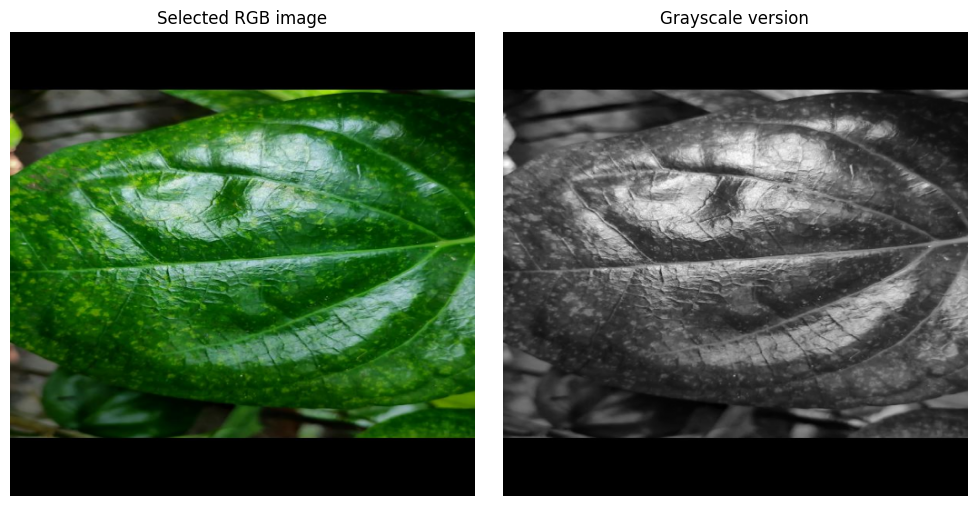

In [5]:
# ============================================================
# Assigned Image Selection
# ============================================================

# Examiner may change these values during the lab exam.
SELECTED_CLASS = "Healthy Leaf"       # Options: CLASS_NAMES
IMAGE_INDEX = 0                       # Change this to use another image from the selected class
TARGET_SIZE = (512, 512)

selected_files = list_image_files(TRAIN_DIR / SELECTED_CLASS)
if len(selected_files) == 0:
    raise FileNotFoundError(f"No images found for class: {SELECTED_CLASS}")

image_path = selected_files[IMAGE_INDEX % len(selected_files)]
rgb_image = read_rgb(image_path, target_size=TARGET_SIZE)
gray_image = to_gray(rgb_image)

print("Selected image:", image_path)
print("RGB shape:", rgb_image.shape)
print("Grayscale shape:", gray_image.shape)
print("Data type:", rgb_image.dtype)

show_images(
    [rgb_image, gray_image],
    ["Selected RGB image", "Grayscale version"],
    cols=2,
    figsize=(10, 5)
)

## 2. Lab Exam Problem Bank

The examiner may assign any one of the following problem types or a modified unseen version.

| Problem ID | Theme | Required Competency |
|---:|---|---|
| 1 | Contrast enhancement and segmentation | point operations, histogram processing, thresholding |
| 2 | Noise restoration and edge detection | noise models, smoothing filters, Sobel/Canny |
| 3 | Frequency-domain filtering and sharpening | DFT, low-pass/high-pass filters, Laplacian comparison |
| 4 | Morphological object extraction | thresholding, opening, closing, connected components |
| 5 | Color-based disease-region analysis | color spaces, masking, morphology, quantitative summary |

Set `ASSIGNED_PROBLEM_ID` according to the examiner's instruction.

In [6]:
# ============================================================
# Assigned Problem Selection
# ============================================================

ASSIGNED_PROBLEM_ID = 1  # Examiner may set: 1, 2, 3, 4, or 5

PROBLEM_BANK = {
    1: {
        "title": "Contrast Enhancement and Segmentation",
        "requirements": [
            "Convert the selected image to grayscale.",
            "Improve contrast using a suitable enhancement method.",
            "Segment the foreground or disease-related region using thresholding.",
            "Apply morphology if needed.",
            "Report at least two quantitative measures."
        ],
    },
    2: {
        "title": "Noise Restoration and Edge Detection",
        "requirements": [
            "Add a controlled noise model to the image.",
            "Restore the noisy image using an appropriate spatial filter.",
            "Apply Sobel or Canny edge detection.",
            "Compare restored and noisy images using PSNR/SSIM.",
            "Comment on edge preservation after restoration."
        ],
    },
    3: {
        "title": "Frequency-Domain Filtering and Sharpening",
        "requirements": [
            "Compute and visualize the 2D DFT magnitude spectrum.",
            "Apply a frequency-domain low-pass or high-pass filter.",
            "Reconstruct the filtered image using inverse DFT.",
            "Compare with a spatial-domain filtering result.",
            "Report sharpness or error-based measures."
        ],
    },
    4: {
        "title": "Morphological Object Extraction",
        "requirements": [
            "Create a binary mask from the selected image.",
            "Apply erosion, dilation, opening, or closing as needed.",
            "Extract the largest object or meaningful components.",
            "Label connected components.",
            "Report component count and component areas."
        ],
    },
    5: {
        "title": "Color-Based Disease-Region Analysis",
        "requirements": [
            "Convert the image to HSV or Lab color space.",
            "Create a color-based mask for visible affected/dry regions.",
            "Refine the mask using morphology.",
            "Overlay the mask on the original image.",
            "Report affected-region percentage."
        ],
    },
}

assigned_problem = PROBLEM_BANK[ASSIGNED_PROBLEM_ID]

print(f"Assigned Problem {ASSIGNED_PROBLEM_ID}: {assigned_problem['title']}")
print("\nRequired outputs:")
for i, req in enumerate(assigned_problem["requirements"], start=1):
    print(f"{i}. {req}")

Assigned Problem 1: Contrast Enhancement and Segmentation

Required outputs:
1. Convert the selected image to grayscale.
2. Improve contrast using a suitable enhancement method.
3. Segment the foreground or disease-related region using thresholding.
4. Apply morphology if needed.
5. Report at least two quantitative measures.


## 3. Student Solution Workspace

The following cells provide a structured workspace. Students may add cells if required. The final answer should contain:

- the selected input image;
- intermediate output images;
- the final processed image or mask;
- a small quantitative table;
- saved output files.

,height,width,channels,gray_min,gray_max,gray_mean,gray_std,laplacian_variance
0,512,512,3,0,236,59.079086,51.92251,342.903606


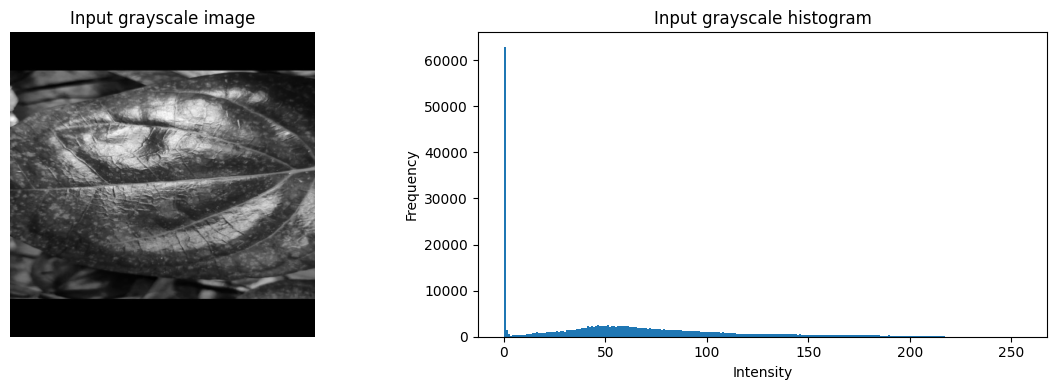

In [7]:
# ============================================================
# Step A: Inspect Input Image
# ============================================================

input_stats = {
    "height": rgb_image.shape[0],
    "width": rgb_image.shape[1],
    "channels": rgb_image.shape[2],
    "gray_min": int(gray_image.min()),
    "gray_max": int(gray_image.max()),
    "gray_mean": float(gray_image.mean()),
    "gray_std": float(gray_image.std()),
    "laplacian_variance": laplacian_variance(gray_image),
}

display(pd.DataFrame([input_stats]))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(gray_image, cmap="gray")
plt.title("Input grayscale image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.hist(gray_image.ravel(), bins=256, range=(0, 255))
plt.title("Input grayscale histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# Step B: Baseline Processing Functions for Exam Problems
# ============================================================
# These functions provide a controlled starting point.
# Students may modify or replace them according to the assigned problem.

def problem_1_contrast_segmentation(gray):
    """
    Baseline solution for contrast enhancement and segmentation.
    """
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)

    _, otsu_mask = cv2.threshold(
        enhanced, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # Choose the foreground orientation that gives a compact leaf-like region.
    if np.mean(otsu_mask == 255) > 0.65:
        otsu_mask = cv2.bitwise_not(otsu_mask)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    refined = cv2.morphologyEx(otsu_mask, cv2.MORPH_OPEN, kernel)
    refined = cv2.morphologyEx(refined, cv2.MORPH_CLOSE, kernel)
    refined = largest_component_mask(refined)

    metrics = {
        "enhanced_mean": float(enhanced.mean()),
        "enhanced_std": float(enhanced.std()),
        "foreground_percent": float(np.mean(refined > 0) * 100),
        "sharpness_laplacian_variance": laplacian_variance(enhanced),
    }

    return {
        "images": [gray, enhanced, otsu_mask, refined],
        "titles": ["Input gray", "CLAHE enhanced", "Otsu mask", "Refined mask"],
        "final": refined,
        "metrics": metrics,
    }

def problem_2_restoration_edges(gray):
    """
    Baseline solution for noise restoration and edge detection.
    """
    noise = rng.normal(0, 20, gray.shape)
    noisy = ensure_uint8(gray.astype(np.float32) + noise)

    mean_filtered = cv2.blur(noisy, (5, 5))
    median_filtered = cv2.medianBlur(noisy, 5)

    # Select the restored image with higher PSNR.
    candidates = {
        "Mean filter": mean_filtered,
        "Median filter": median_filtered,
    }
    best_name = max(candidates, key=lambda k: psnr(gray, candidates[k]))
    restored = candidates[best_name]

    sobel_x = cv2.Sobel(restored, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(restored, cv2.CV_64F, 0, 1, ksize=3)
    gradient = normalize_to_uint8(np.sqrt(sobel_x ** 2 + sobel_y ** 2))
    canny = cv2.Canny(restored, 50, 150)

    metrics = {
        "noisy_psnr": psnr(gray, noisy),
        "restored_psnr": psnr(gray, restored),
        "noisy_ssim": ssim_score(gray, noisy),
        "restored_ssim": ssim_score(gray, restored),
        "selected_restoration_filter": best_name,
        "canny_edge_density": edge_density(canny),
    }

    return {
        "images": [gray, noisy, restored, gradient, canny],
        "titles": ["Input gray", "Gaussian noisy", f"Restored ({best_name})", "Sobel magnitude", "Canny edges"],
        "final": canny,
        "metrics": metrics,
    }

def make_gaussian_frequency_mask(shape, cutoff=40, high_pass=False):
    """
    Create Gaussian low-pass or high-pass mask for frequency-domain filtering.
    """
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2
    y, x = np.ogrid[:rows, :cols]
    distance_sq = (y - crow) ** 2 + (x - ccol) ** 2
    low_pass = np.exp(-distance_sq / (2 * (cutoff ** 2)))
    if high_pass:
        return 1 - low_pass
    return low_pass

def frequency_filter(gray, cutoff=40, high_pass=False):
    """
    Apply a Gaussian frequency-domain filter and reconstruct the image.
    """
    f = np.fft.fft2(gray)
    fshift = np.fft.fftshift(f)

    mask = make_gaussian_frequency_mask(gray.shape, cutoff=cutoff, high_pass=high_pass)
    filtered_shift = fshift * mask

    inverse_shift = np.fft.ifftshift(filtered_shift)
    reconstructed = np.fft.ifft2(inverse_shift)
    reconstructed = np.abs(reconstructed)

    magnitude_spectrum = np.log1p(np.abs(fshift))
    return normalize_to_uint8(reconstructed), normalize_to_uint8(magnitude_spectrum), normalize_to_uint8(mask * 255)

def problem_3_frequency_filtering(gray):
    """
    Baseline solution for frequency-domain filtering and sharpening.
    """
    low_pass, spectrum, lp_mask = frequency_filter(gray, cutoff=35, high_pass=False)
    high_pass, _, hp_mask = frequency_filter(gray, cutoff=35, high_pass=True)

    laplacian = cv2.Laplacian(gray, cv2.CV_64F)
    laplacian_abs = normalize_to_uint8(np.abs(laplacian))

    metrics = {
        "low_pass_psnr": psnr(gray, low_pass),
        "high_pass_energy": float(np.mean(high_pass.astype(np.float32) ** 2)),
        "laplacian_energy": float(np.mean(laplacian_abs.astype(np.float32) ** 2)),
        "input_sharpness": laplacian_variance(gray),
        "low_pass_sharpness": laplacian_variance(low_pass),
    }

    return {
        "images": [gray, spectrum, lp_mask, low_pass, hp_mask, high_pass, laplacian_abs],
        "titles": ["Input gray", "Log magnitude spectrum", "Gaussian LP mask", "Low-pass result", "Gaussian HP mask", "High-pass result", "Laplacian response"],
        "final": high_pass,
        "metrics": metrics,
    }

def problem_4_morphological_extraction(gray):
    """
    Baseline solution for morphology and connected-component extraction.
    """
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    _, mask = cv2.threshold(
        blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    if np.mean(mask == 255) > 0.65:
        mask = cv2.bitwise_not(mask)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
    opened = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)
    largest = largest_component_mask(closed)

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        (closed > 0).astype(np.uint8), connectivity=8
    )

    component_count = max(num_labels - 1, 0)
    foreground_areas = stats[1:, cv2.CC_STAT_AREA] if num_labels > 1 else np.array([])

    metrics = {
        "component_count": int(component_count),
        "largest_component_area": int(foreground_areas.max()) if len(foreground_areas) else 0,
        "total_foreground_area": int(foreground_areas.sum()) if len(foreground_areas) else 0,
        "foreground_percent": float(np.mean(largest > 0) * 100),
    }

    return {
        "images": [gray, mask, opened, closed, largest],
        "titles": ["Input gray", "Initial Otsu mask", "Opening", "Closing", "Largest component"],
        "final": largest,
        "metrics": metrics,
    }

def problem_5_color_region_analysis(rgb):
    """
    Baseline solution for color-based affected-region analysis.
    """
    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)

    # General mask for yellow/brown/dry-looking regions.
    # Examiner may ask students to adjust these bounds for a specific image.
    lower = np.array([10, 40, 40])
    upper = np.array([45, 255, 255])
    color_mask = cv2.inRange(hsv, lower, upper)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    refined = cv2.morphologyEx(color_mask, cv2.MORPH_OPEN, kernel)
    refined = cv2.morphologyEx(refined, cv2.MORPH_CLOSE, kernel)

    overlay = rgb.copy()
    overlay[refined > 0] = (255, 0, 0)
    blended = cv2.addWeighted(rgb, 0.65, overlay, 0.35, 0)

    metrics = {
        "affected_region_percent": float(np.mean(refined > 0) * 100),
        "mean_hue_masked": float(hsv[:, :, 0][refined > 0].mean()) if np.any(refined > 0) else 0.0,
        "mask_area_pixels": int(np.count_nonzero(refined)),
    }

    return {
        "images": [rgb, hsv[:, :, 0], color_mask, refined, blended],
        "titles": ["Input RGB", "Hue channel", "Initial HSV mask", "Refined mask", "Overlay"],
        "final": blended,
        "metrics": metrics,
    }

print("Baseline processing functions are ready.")

Baseline processing functions are ready.


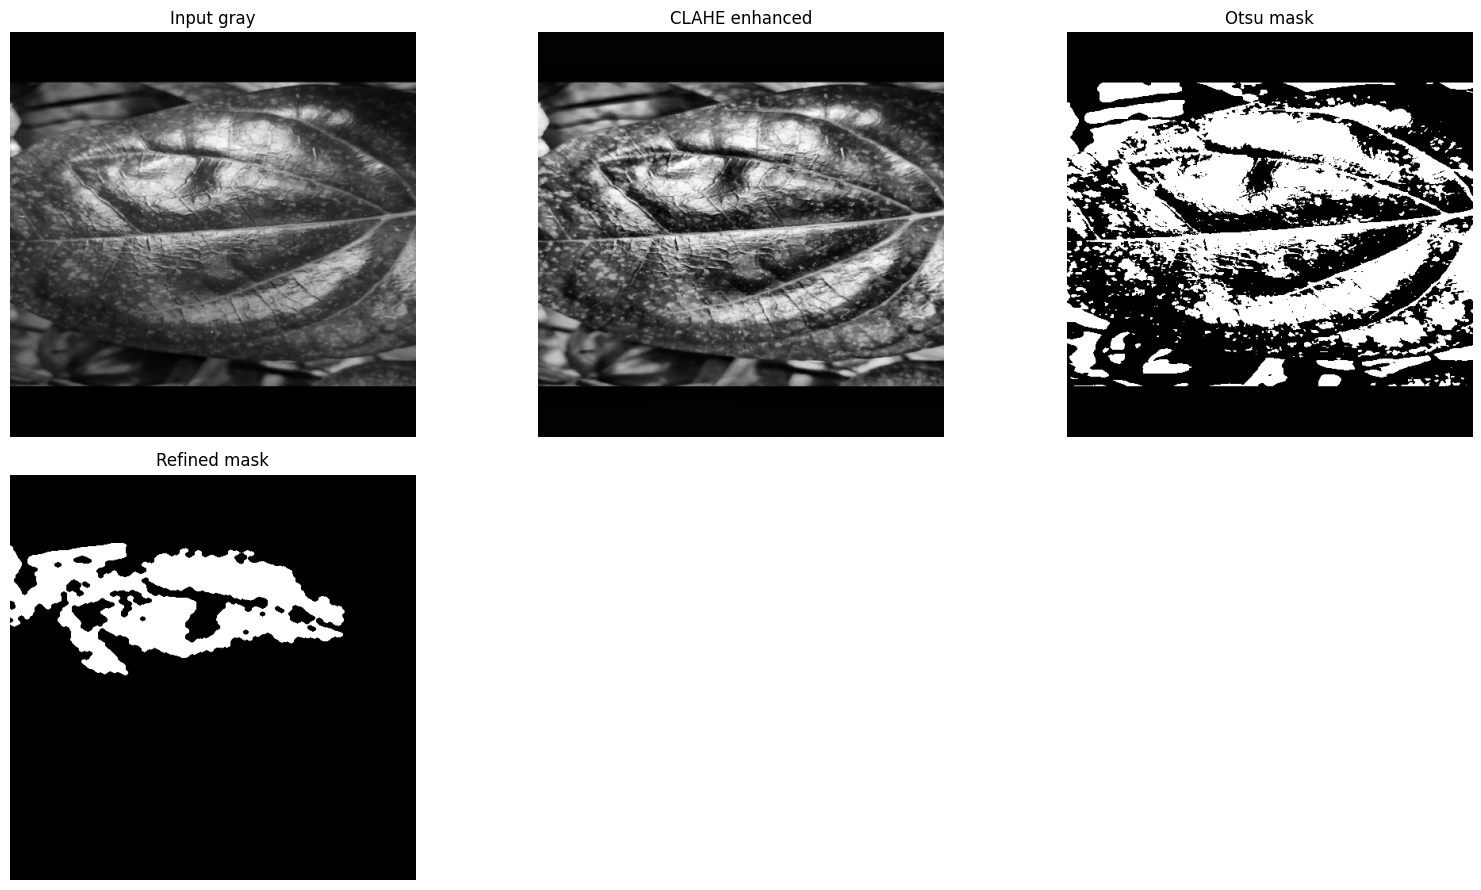

,enhanced_mean,enhanced_std,foreground_percent,sharpness_laplacian_variance
0,76.506924,66.648135,12.717056,925.330433


In [9]:
# ============================================================
# Step C: Run the Assigned Problem Baseline
# ============================================================
# Students should treat this as a starting point and improve/modify it
# according to the examiner's exact instruction.

if ASSIGNED_PROBLEM_ID == 1:
    result = problem_1_contrast_segmentation(gray_image)
elif ASSIGNED_PROBLEM_ID == 2:
    result = problem_2_restoration_edges(gray_image)
elif ASSIGNED_PROBLEM_ID == 3:
    result = problem_3_frequency_filtering(gray_image)
elif ASSIGNED_PROBLEM_ID == 4:
    result = problem_4_morphological_extraction(gray_image)
elif ASSIGNED_PROBLEM_ID == 5:
    result = problem_5_color_region_analysis(rgb_image)
else:
    raise ValueError("ASSIGNED_PROBLEM_ID must be one of: 1, 2, 3, 4, 5")

show_images(
    result["images"],
    result["titles"],
    cols=3,
    figsize=(16, 9)
)

metrics_df = pd.DataFrame([result["metrics"]])
display(metrics_df)

## 4. Independent Solution Cell

Students should write their final solution below. The baseline result above is only a starting point. During the exam, the examiner may require a different method, parameter set, or image.

,enhanced_mean,enhanced_std,foreground_percent,sharpness_laplacian_variance
0,76.506924,66.648135,12.717056,925.330433


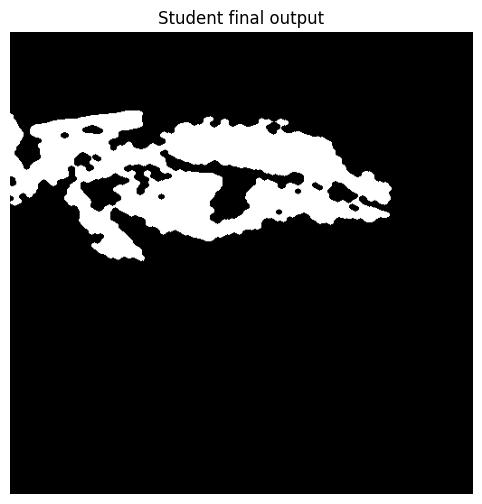

In [10]:
# ============================================================
# Student Final Solution
# ============================================================
# Write your final exam solution here.
# You may use the helper functions defined above, but your method,
# parameter choices, and output explanation must match the assigned problem.

# Example structure:
# 1. Load or reuse rgb_image / gray_image
# 2. Apply preprocessing
# 3. Apply the main DIP method
# 4. Generate final output
# 5. Compute metrics
# 6. Save outputs

student_final_output = result["final"]
student_metrics = result["metrics"]

display(pd.DataFrame([student_metrics]))

if student_final_output.ndim == 2:
    plt.imshow(student_final_output, cmap="gray")
else:
    plt.imshow(student_final_output)
plt.title("Student final output")
plt.axis("off")
plt.show()

## 5. Save Required Outputs

The following cell saves the input image, final output, and metric table. These files may be submitted with the notebook.

In [11]:
# ============================================================
# Save Exam Outputs
# ============================================================

input_path = save_image_rgb_or_gray(rgb_image, "lab13_input_rgb.png")

if student_final_output.ndim == 2:
    final_path = save_image_rgb_or_gray(student_final_output, "lab13_final_output.png")
else:
    final_path = save_image_rgb_or_gray(student_final_output, "lab13_final_output.png")

metrics_path = OUTPUT_DIR / "lab13_metrics.csv"
pd.DataFrame([student_metrics]).to_csv(metrics_path, index=False)

print("Saved files:")
print(input_path)
print(final_path)
print(metrics_path)

Saved files:
/kaggle/working/cse438_lab13_exam_outputs/lab13_input_rgb.png
/kaggle/working/cse438_lab13_exam_outputs/lab13_final_output.png
/kaggle/working/cse438_lab13_exam_outputs/lab13_metrics.csv


In [12]:
# ============================================================
# Create a Submission ZIP File
# ============================================================
# This creates a small output archive containing generated images and metrics.
# The notebook file itself should also be submitted according to the examiner's instruction.

zip_base = Path("/kaggle/working/cse438_lab13_exam_submission")
zip_path = shutil.make_archive(str(zip_base), "zip", root_dir=OUTPUT_DIR)

print("Submission archive created:")
print(zip_path)

Submission archive created:
/kaggle/working/cse438_lab13_exam_submission.zip


## 6. Viva Preparation Coverage

The examiner may ask 3–5 questions from any previous lab topic. Students should be prepared to explain both the concept and the code used in their solution.

### Sample Viva Question Bank

1. What is the difference between sampling and quantization?
2. Why does aliasing occur during downsampling?
3. What is the difference between 4-neighbor and 8-neighbor adjacency?
4. How does contrast stretching differ from histogram equalization?
5. Why is logarithmic transformation useful for displaying Fourier magnitude spectra?
6. How does gamma correction affect dark and bright regions?
7. What is the difference between global histogram equalization and CLAHE?
8. Why does median filtering work well for salt-and-pepper noise?
9. What is the difference between first-order and second-order derivative filters?
10. Why does Canny edge detection use hysteresis thresholding?
11. What does the center of a shifted DFT spectrum represent?
12. What is the difference between ideal, Butterworth, and Gaussian filters?
13. Why does high-pass filtering emphasize edges and fine details?
14. What is the purpose of the Wiener filter in image restoration?
15. What do PSNR and SSIM measure?
16. Why does Otsu's method work well when the histogram is approximately bimodal?
17. What is the difference between erosion and dilation?
18. How do opening and closing modify a binary object?
19. What information is returned by connected-component labeling?
20. Why must the selected method depend on image quality, noise, illumination, and task objective?

## 7. Examiner Marking Guide

| Criterion | Marks | Evaluation Focus |
|---|---:|---|
| Correct method selection | 2 | Appropriate algorithm for the assigned problem |
| Working implementation | 3 | Code runs without error and produces output |
| Intermediate visualization | 1 | Input, intermediate, and final results shown clearly |
| Quantitative evaluation | 1 | Suitable use of metrics such as PSNR, SSIM, IoU, edge density, or component count |
| Explanation and comments | 1 | Code is readable and major steps are explained |
| Viva response | 2 | Correct conceptual explanation and relation to implemented code |

Total marks may be adjusted by the examiner according to the official lab-exam policy.

In [13]:
# Summary:
# This Lab 13 notebook provides an exam-ready workspace for solving an assigned
# Digital Image Processing problem using the Betel Leaf dataset. It includes dataset
# loading, reusable utility functions, a controlled problem bank, structured solution
# cells, output-saving code, metric reporting, and viva preparation coverage.